In [2]:
import pandas as pd
import numpy as np

# Veri setini yükleyelim
df = pd.read_csv("Churn_Modelling.csv")

# İlk 5 satırı görüntüleyelim
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Satır ve sütun sayısı
df.shape


(10000, 14)

In [4]:
# Sütunlar ve veri tipleri
df.dtypes


RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [5]:
# Eksik değerler
df.isnull().sum()


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
# Temel istatistikler
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns

# Her kategorik sütunun benzersiz değer sayısı
{col: df[col].nunique() for col in categorical_cols}


{'Surname': 2932, 'Geography': 3, 'Gender': 2}

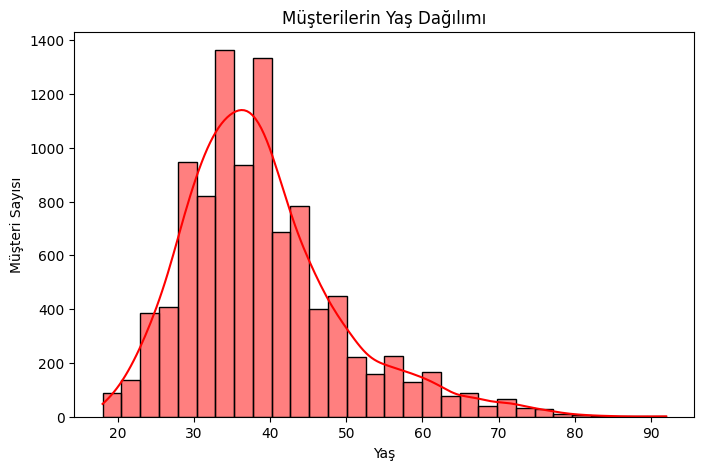

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='red')
plt.title("Müşterilerin Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Müşteri Sayısı")
plt.show()


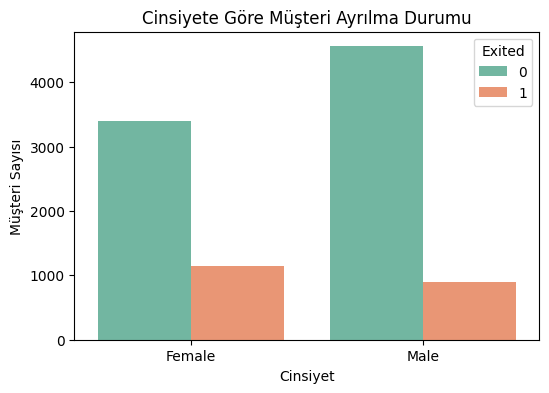

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df, palette='Set2')
plt.title("Cinsiyete Göre Müşteri Ayrılma Durumu")
plt.xlabel("Cinsiyet")
plt.ylabel("Müşteri Sayısı")
plt.show()


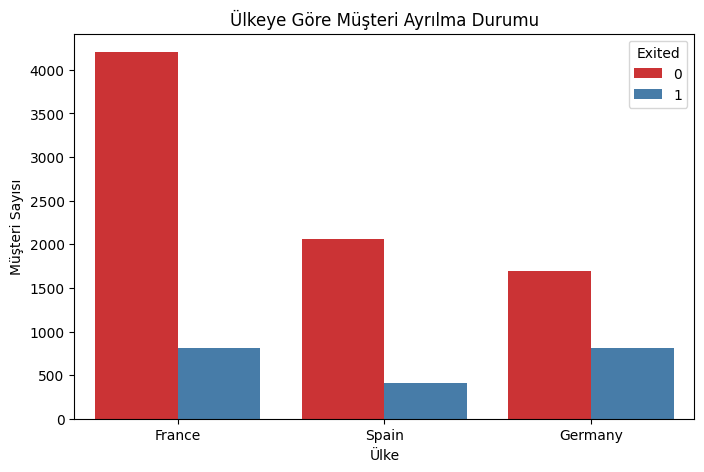

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='Geography', hue='Exited', data=df, palette='Set1')
plt.title("Ülkeye Göre Müşteri Ayrılma Durumu")
plt.xlabel("Ülke")
plt.ylabel("Müşteri Sayısı")
plt.show()


C:\Users\CASPER\AppData\Local\Temp\ipykernel_12388\1787006607.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df, palette='coolwarm')


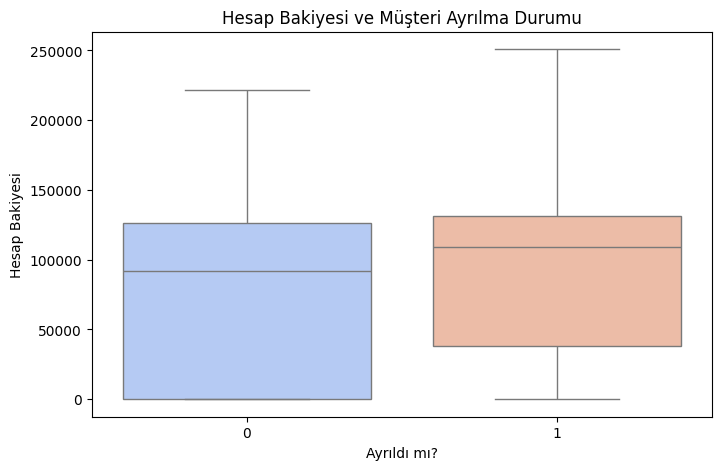

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Balance', data=df, palette='coolwarm')
plt.title("Hesap Bakiyesi ve Müşteri Ayrılma Durumu")
plt.xlabel("Ayrıldı mı?")
plt.ylabel("Hesap Bakiyesi")
plt.show()


C:\Users\CASPER\AppData\Local\Temp\ipykernel_12388\617874477.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='CreditScore', data=df, palette='pastel')


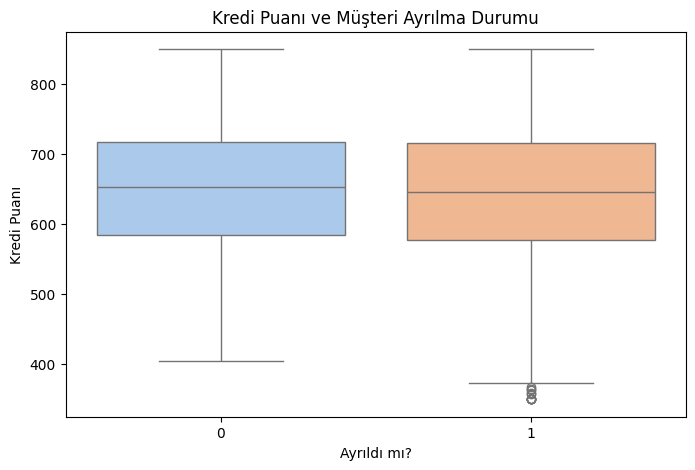

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='CreditScore', data=df, palette='pastel')
plt.title("Kredi Puanı ve Müşteri Ayrılma Durumu")
plt.xlabel("Ayrıldı mı?")
plt.ylabel("Kredi Puanı")
plt.show()


C:\Users\CASPER\AppData\Local\Temp\ipykernel_12388\3979850444.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Tenure', data=df, palette='Set3')


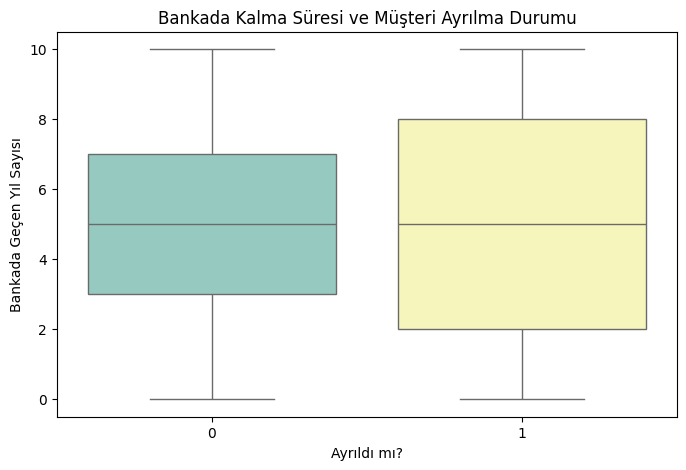

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Tenure', data=df, palette='Set3')
plt.title("Bankada Kalma Süresi ve Müşteri Ayrılma Durumu")
plt.xlabel("Ayrıldı mı?")
plt.ylabel("Bankada Geçen Yıl Sayısı")
plt.show()


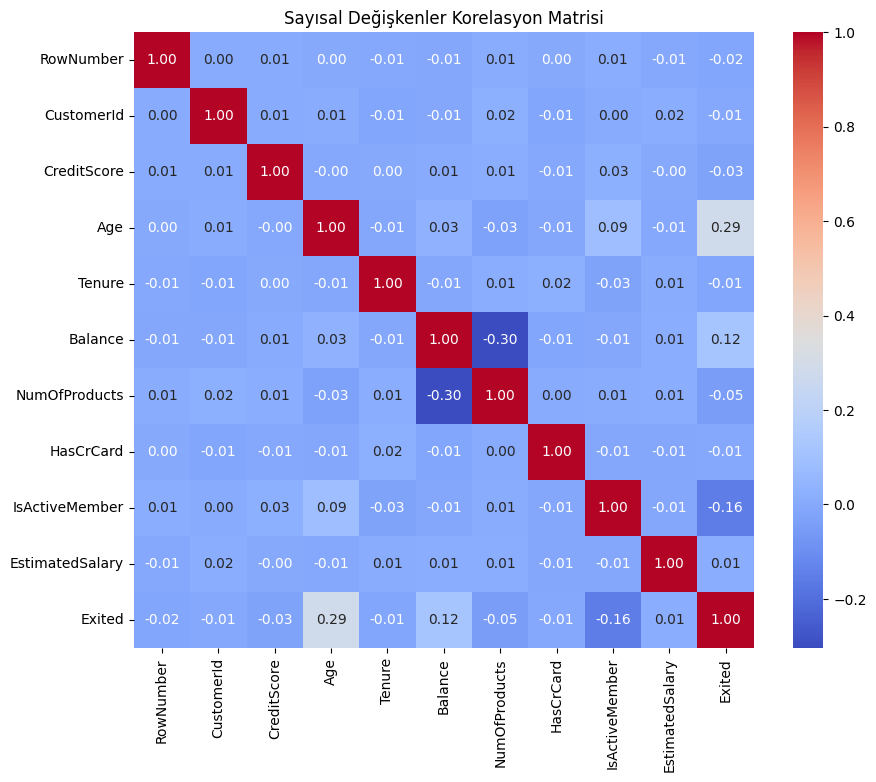

In [16]:
plt.figure(figsize=(10,8))

# Sayısal sütunları seçelim
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Korelasyon matrisi
corr_matrix = df[numerical_cols].corr()

# Isı haritasını çizelim
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Sayısal Değişkenler Korelasyon Matrisi")
plt.show()


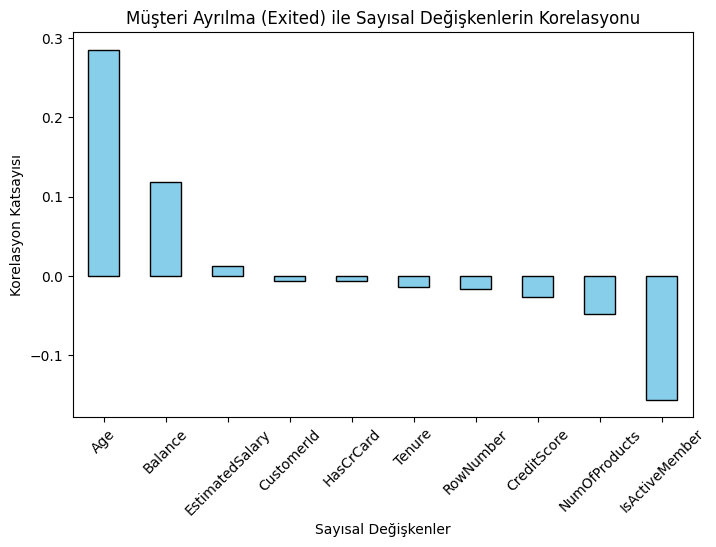

In [17]:
# Sayısal sütunlar
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Exited ile korelasyon
corr_exited = df[numerical_cols].corr()['Exited'].sort_values(ascending=False)

# Exited ile olan korelasyonu görselleştirelim (Exited hariç)
plt.figure(figsize=(8,5))
corr_exited.drop('Exited').plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Müşteri Ayrılma (Exited) ile Sayısal Değişkenlerin Korelasyonu")
plt.ylabel("Korelasyon Katsayısı")
plt.xlabel("Sayısal Değişkenler")
plt.xticks(rotation=45)
plt.show()


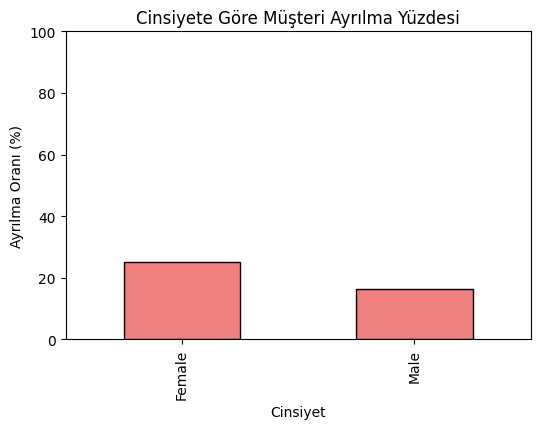

In [18]:
gender_exited_pct = df.groupby('Gender')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
gender_exited_pct.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title("Cinsiyete Göre Müşteri Ayrılma Yüzdesi")
plt.ylabel("Ayrılma Oranı (%)")
plt.xlabel("Cinsiyet")
plt.ylim(0,100)
plt.show()


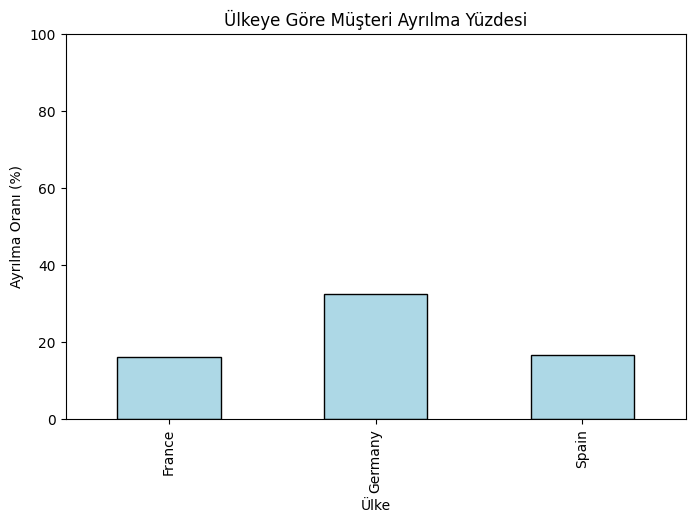

In [19]:
geo_exited_pct = df.groupby('Geography')['Exited'].mean() * 100

plt.figure(figsize=(8,5))
geo_exited_pct.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title("Ülkeye Göre Müşteri Ayrılma Yüzdesi")
plt.ylabel("Ayrılma Oranı (%)")
plt.xlabel("Ülke")
plt.ylim(0,100)
plt.show()


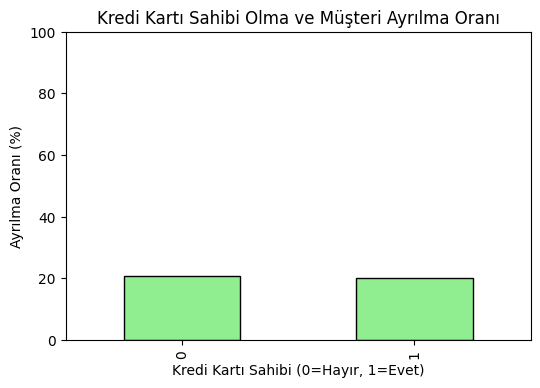

In [20]:
creditcard_exited_pct = df.groupby('HasCrCard')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
creditcard_exited_pct.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Kredi Kartı Sahibi Olma ve Müşteri Ayrılma Oranı")
plt.ylabel("Ayrılma Oranı (%)")
plt.xlabel("Kredi Kartı Sahibi (0=Hayır, 1=Evet)")
plt.ylim(0,100)
plt.show()


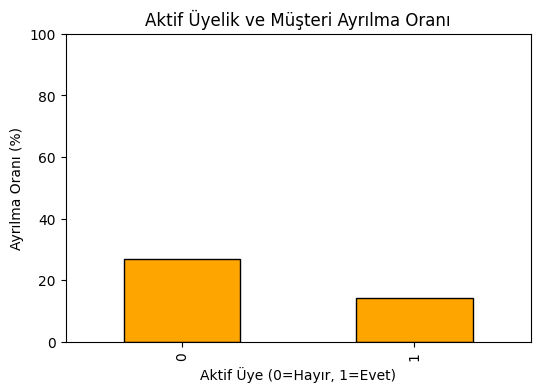

In [21]:
active_exited_pct = df.groupby('IsActiveMember')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
active_exited_pct.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Aktif Üyelik ve Müşteri Ayrılma Oranı")
plt.ylabel("Ayrılma Oranı (%)")
plt.xlabel("Aktif Üye (0=Hayır, 1=Evet)")
plt.ylim(0,100)
plt.show()


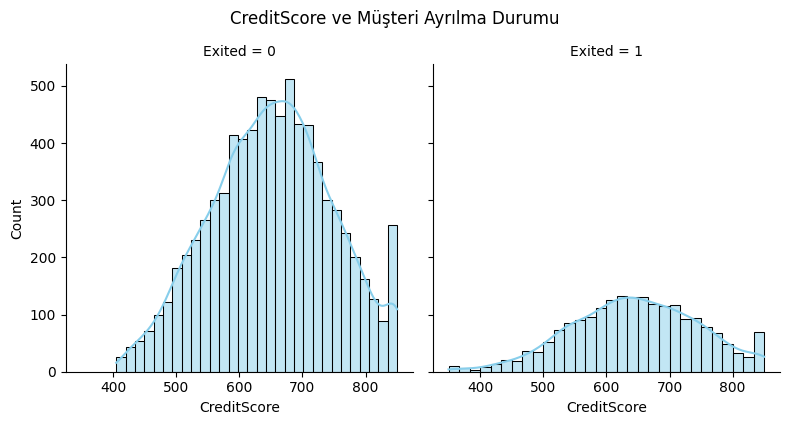

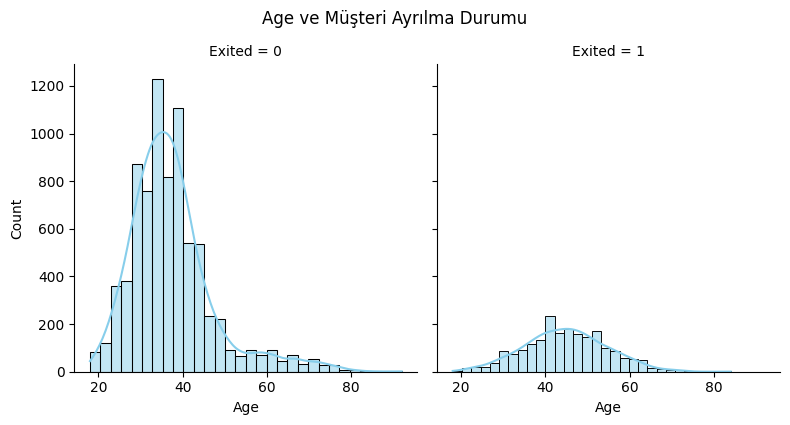

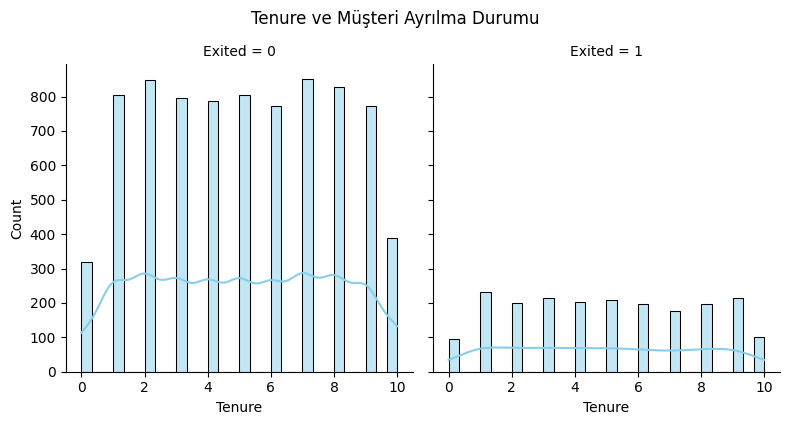

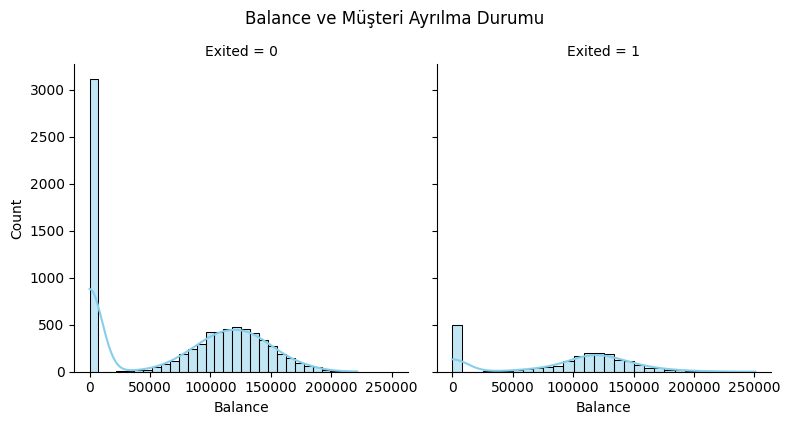

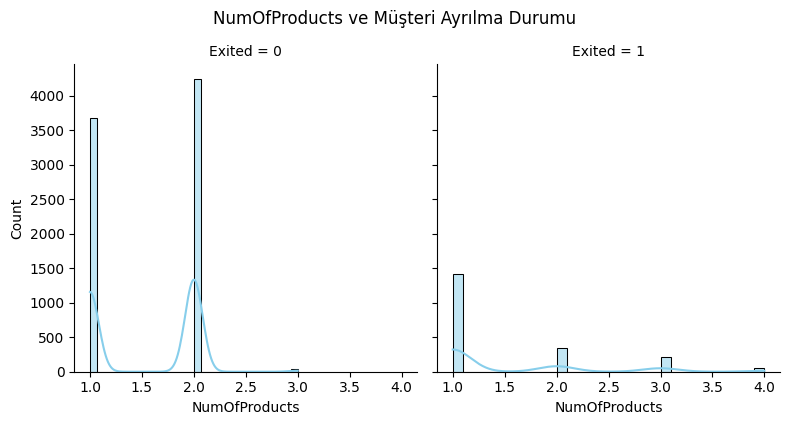

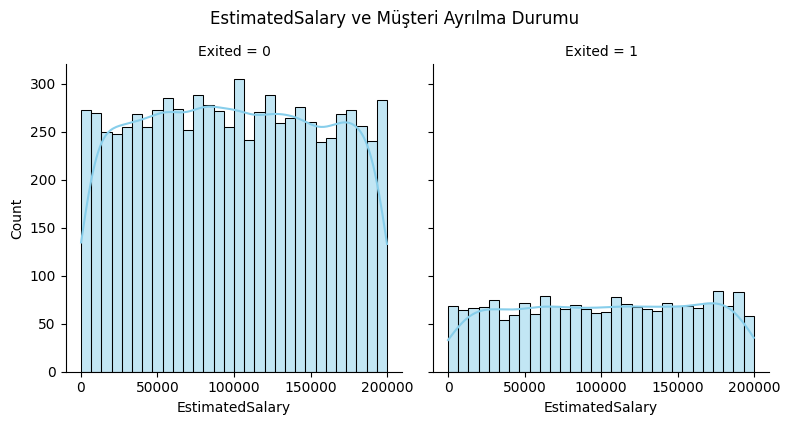

In [22]:
# FacetGrid ile birden fazla sayısal değişkeni Exited durumuna göre görselleştirelim
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for col in numerical_cols:
    g = sns.FacetGrid(df, col='Exited', height=4, aspect=1)
    g.map(sns.histplot, col, bins=30, kde=True, color='skyblue')
    g.fig.suptitle(f"{col} ve Müşteri Ayrılma Durumu", y=1.05)
    plt.show()


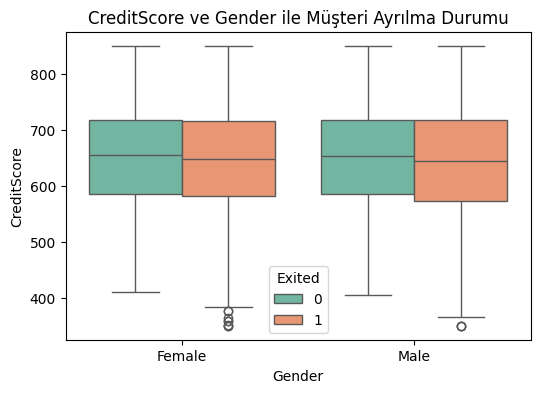

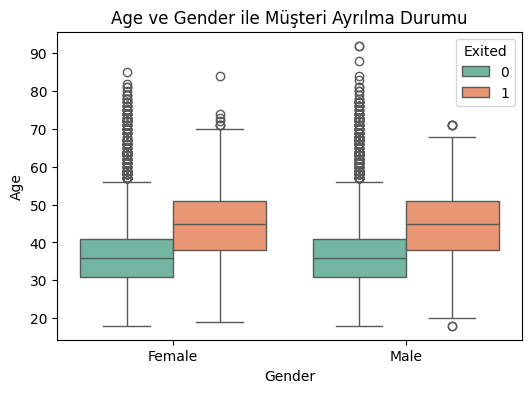

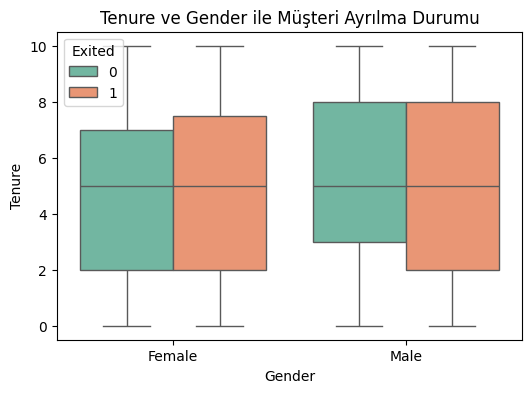

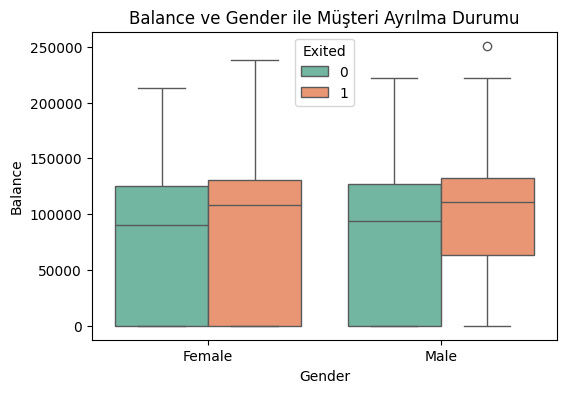

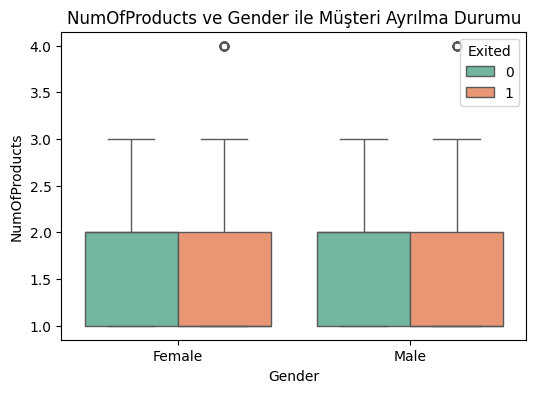

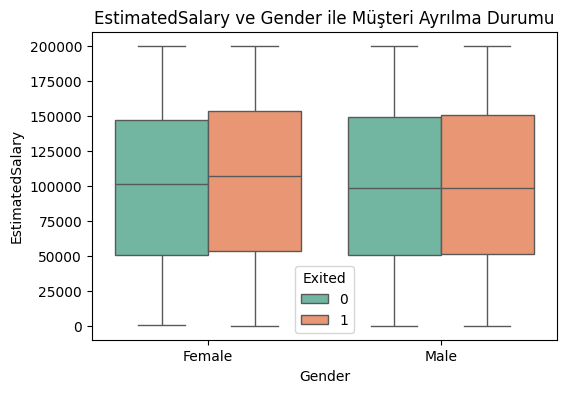

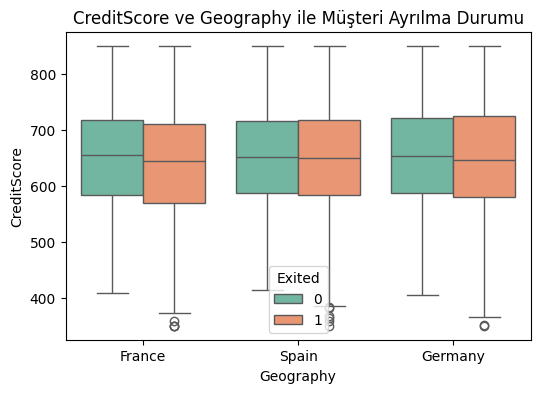

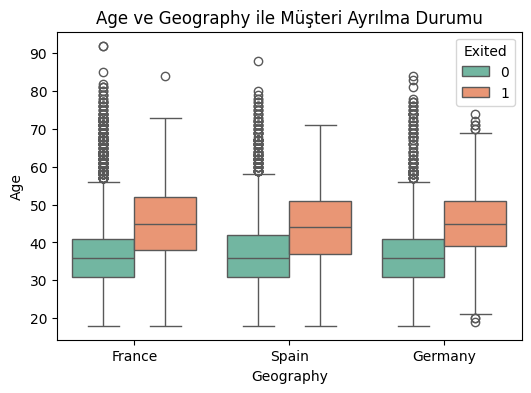

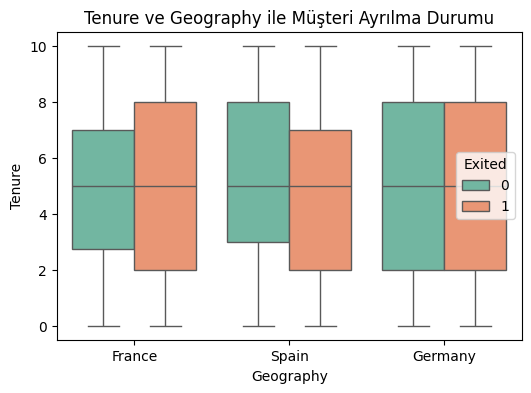

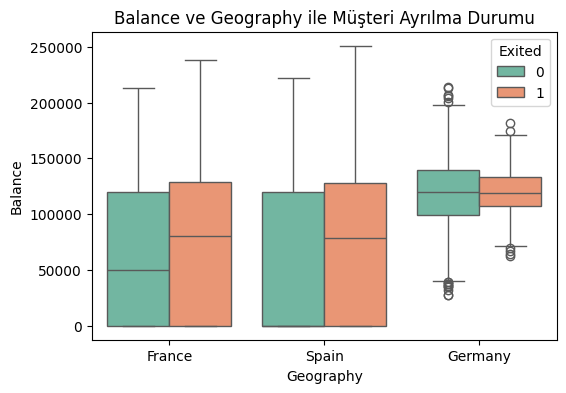

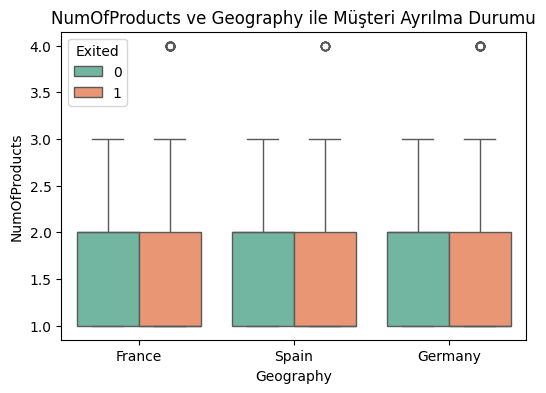

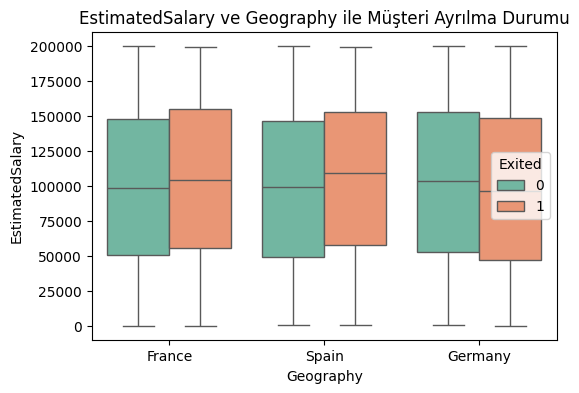

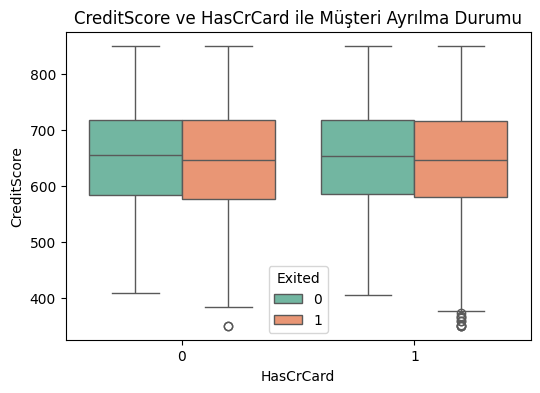

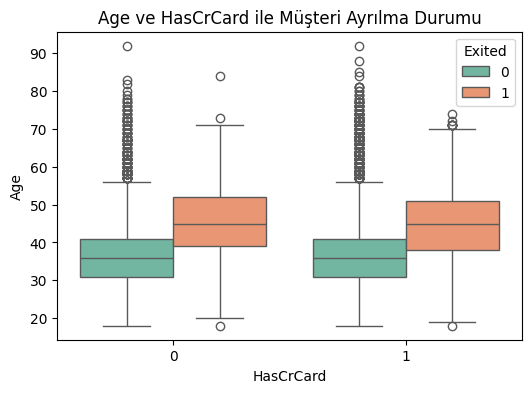

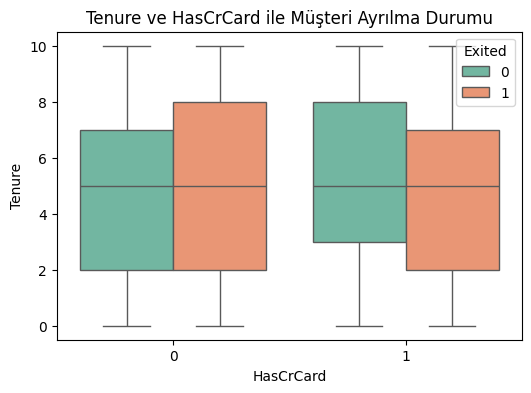

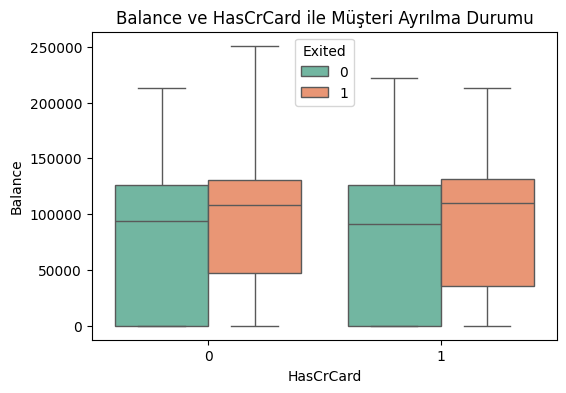

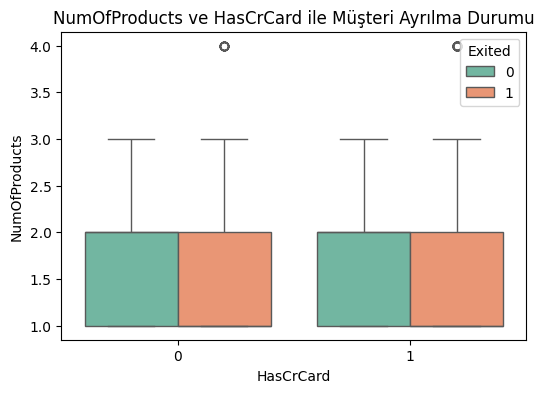

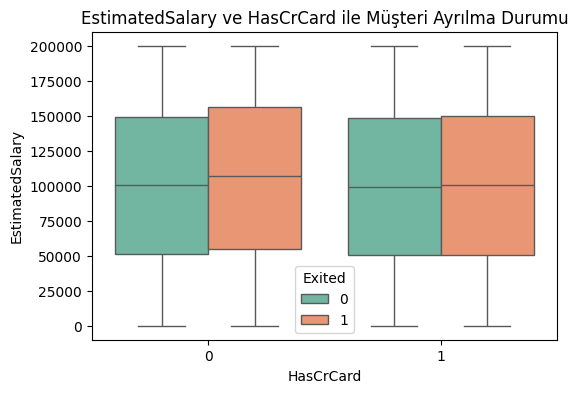

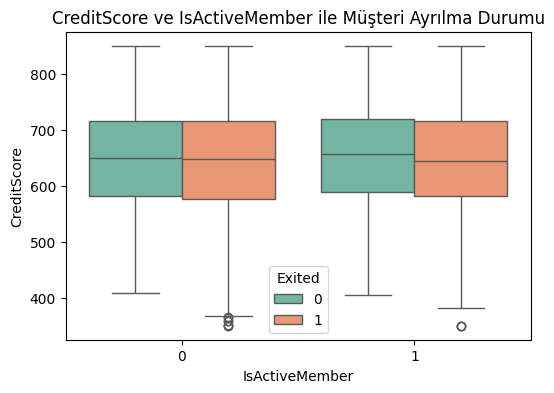

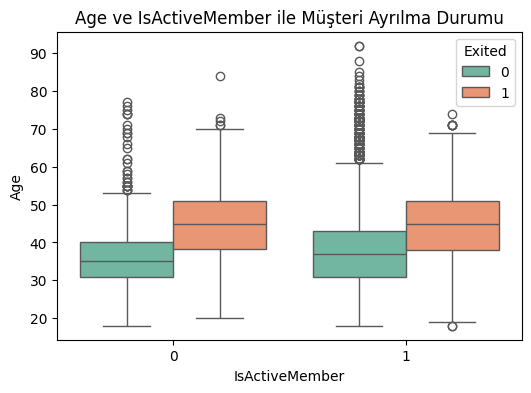

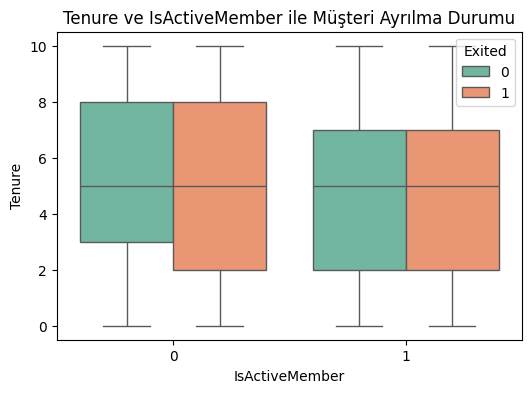

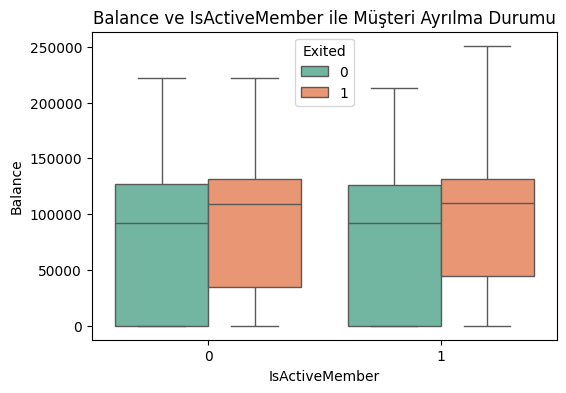

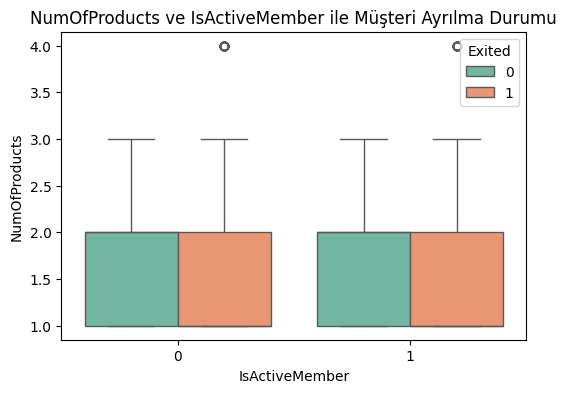

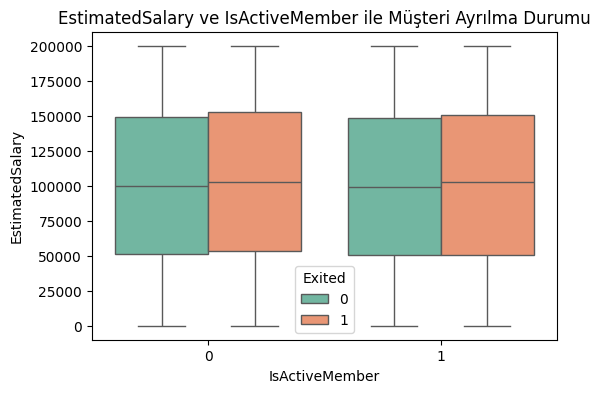

In [23]:
categorical_cols = ['Gender', 'Geography', 'HasCrCard', 'IsActiveMember']
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for cat in categorical_cols:
    for num in numerical_cols:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=cat, y=num, hue='Exited', data=df, palette='Set2')
        plt.title(f"{num} ve {cat} ile Müşteri Ayrılma Durumu")
        plt.show()


In [2]:
# Gerekli kütüphaneler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# Veri setini yükleyelim
df = pd.read_csv("Churn_Modelling.csv")


In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Sayısal ve kategorik sütunları seçelim
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_cols = ['Gender', 'Geography', 'HasCrCard', 'IsActiveMember']

# Dropdown menü oluştur
num_dropdown = widgets.Dropdown(
    options=numerical_cols,
    description='Sayısal Değişken:'
)

cat_dropdown = widgets.Dropdown(
    options=[None] + categorical_cols,
    description='Kategorik Değişken:'
)

def plot_interactive(num_col, cat_col):
    plt.figure(figsize=(8,5))
    if cat_col:
        sns.boxplot(x=cat_col, y=num_col, hue='Exited', data=df, palette='Set2')
        plt.title(f"{num_col} ve {cat_col} ile Müşteri Ayrılma Durumu")
    else:
        sns.boxplot(x='Exited', y=num_col, data=df, palette='Set2')
        plt.title(f"{num_col} ve Müşteri Ayrılma Durumu")
    plt.show()

# Interaktif widget göster
widgets.interact(plot_interactive, num_col=num_dropdown, cat_col=cat_dropdown)


interactive(children=(Dropdown(description='Sayısal Değişken:', options=('CreditScore', 'Age', 'Tenure', 'Bala…

<function __main__.plot_interactive(num_col, cat_col)>

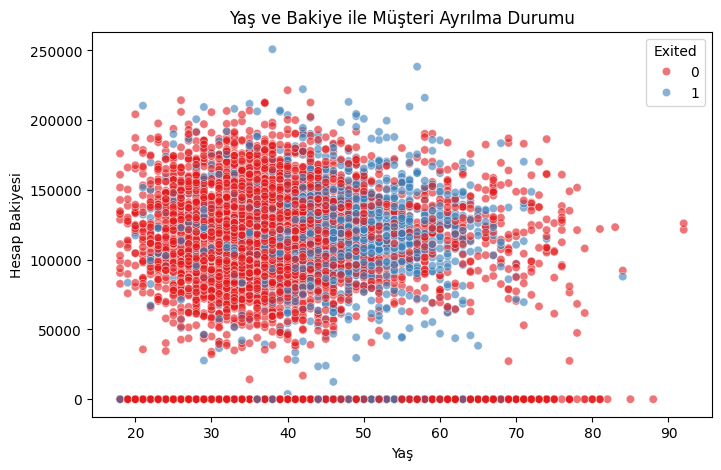

In [4]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Balance', hue='Exited', data=df, palette='Set1', alpha=0.6)
plt.title("Yaş ve Bakiye ile Müşteri Ayrılma Durumu")
plt.xlabel("Yaş")
plt.ylabel("Hesap Bakiyesi")
plt.show()


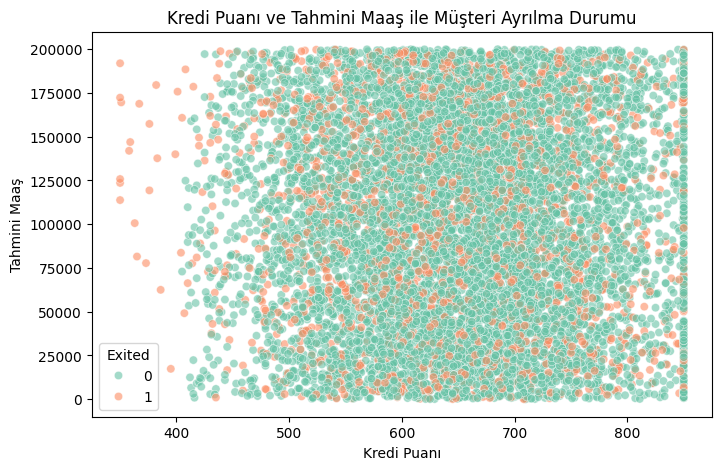

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='CreditScore', y='EstimatedSalary', hue='Exited', data=df, palette='Set2', alpha=0.6)
plt.title("Kredi Puanı ve Tahmini Maaş ile Müşteri Ayrılma Durumu")
plt.xlabel("Kredi Puanı")
plt.ylabel("Tahmini Maaş")
plt.show()


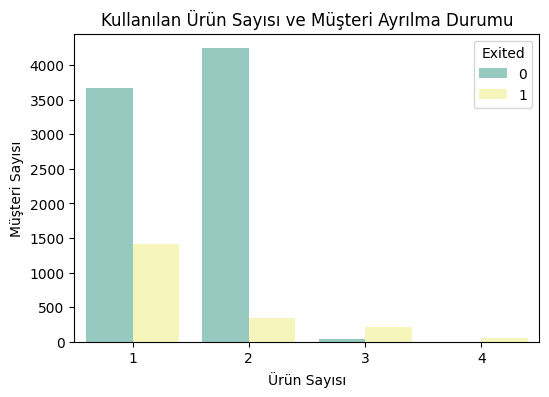

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='Set3')
plt.title("Kullanılan Ürün Sayısı ve Müşteri Ayrılma Durumu")
plt.xlabel("Ürün Sayısı")
plt.ylabel("Müşteri Sayısı")
plt.show()


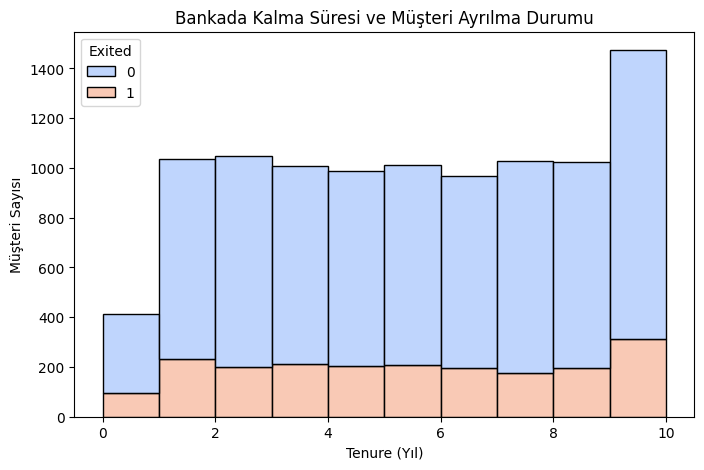

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Tenure', hue='Exited', multiple='stack', bins=10, palette='coolwarm')
plt.title("Bankada Kalma Süresi ve Müşteri Ayrılma Durumu")
plt.xlabel("Tenure (Yıl)")
plt.ylabel("Müşteri Sayısı")
plt.show()
